Dataset Loaded: (20, 18)

Top Vendors:
                            vendor_name  performance_score
3     belagavi_veg_growers_association           0.936320
10       shimoga_agri_tech_cooperative           0.883822
7                     campco_mangaluru           0.790957
2           bagalkot_onion_growers_fpc           0.759799
16  dakshina_kannada_exporters_network           0.724813
15   kodagu_district_spice_cooperative           0.621797
18                  tumkur_agro_supply           0.617333
4            mysore_spices_&_herbs_hub           0.613693
19     mandya_organic_farmers_alliance           0.592801
13        chikkamagaluru_spice_traders           0.584457

Worst Vendors:
                           vendor_name  performance_score
11        phondaghat_pharmacy_&_honey           0.108762
9   sahaja_samrudha_organic_producers           0.261771
1             hubli_fresh_produce_co.           0.272427
8                       tapcms_hassan           0.382201
17                  

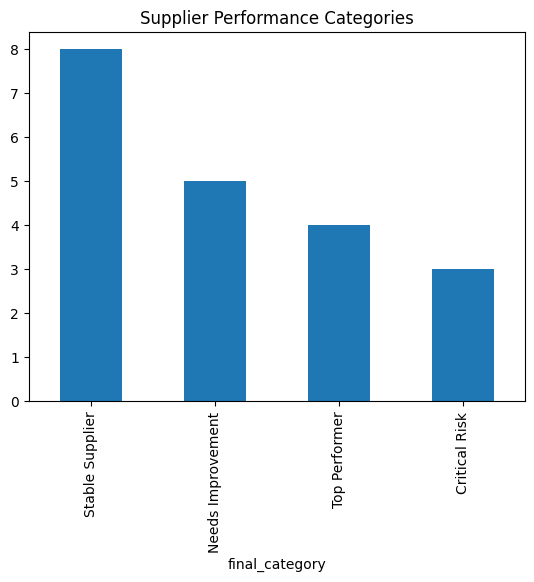

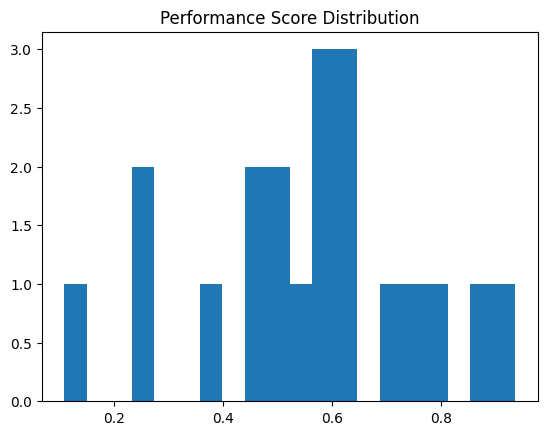


KPI Summary:
Total Suppliers : 20
Top Performers : 4
Critical Suppliers : 3
Avg Performance Score : 0.5611419277704986

Day 20 Completed Successfully


In [2]:
# ==========================================================
# DAY 20 - SUPPLIER PERFORMANCE EVALUATION
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

INPUT_FILE = PROJECT_ROOT / "03_processed_data/spoilage_analysis.csv"
OUTPUT_FILE = PROJECT_ROOT / "03_processed_data/supplier_final_evaluation.csv"

df = pd.read_csv(INPUT_FILE)

print("Dataset Loaded:", df.shape)

# ----------------------------------------------------------
# 1. NORMALIZE SPOILAGE (for scoring)
# ----------------------------------------------------------

df["spoilage_score"] = (
    (df["spoilage_rate"] - df["spoilage_rate"].min()) /
    (df["spoilage_rate"].max() - df["spoilage_rate"].min())
)
# ----------------------------------------------------------
# 2. RECREATE RELIABILITY & RISK (FIX)
# ----------------------------------------------------------

# Normalize defect (bad)
df["defect_score"] = (
    (df["avg_defect"] - df["avg_defect"].min()) /
    (df["avg_defect"].max() - df["avg_defect"].min())
)

# Normalize cost (bad)
df["cost_score"] = (
    (df["avg_cost"] - df["avg_cost"].min()) /
    (df["avg_cost"].max() - df["avg_cost"].min())
)

# Reliability = low defect + low cost
df["reliability_score"] = (
    (1 - df["defect_score"]) * 0.6 +
    (1 - df["cost_score"]) * 0.4
)

# Risk = high defect + high spoilage
df["risk_score"] = (
    df["defect_score"] * 0.5 +
    df["spoilage_score"] * 0.5
)
df["performance_score"] = (
    df["reliability_score"] * 0.5 +
    (1 - df["risk_score"]) * 0.3 +
    (1 - df["spoilage_score"]) * 0.2
)

# ----------------------------------------------------------
# 3. RANKING
# ----------------------------------------------------------

df["performance_rank"] = df["performance_score"].rank(ascending=False)

# ----------------------------------------------------------
# 4. FINAL CATEGORY
# ----------------------------------------------------------

def final_category(score):
    if score >= 0.75:
        return "Top Performer"
    elif score >= 0.55:
        return "Stable Supplier"
    elif score >= 0.35:
        return "Needs Improvement"
    else:
        return "Critical Risk"

df["final_category"] = df["performance_score"].apply(final_category)

# ----------------------------------------------------------
# 5. DECISION FRAMEWORK
# ----------------------------------------------------------

def decision(row):
    if row["final_category"] == "Top Performer":
        return "Increase Procurement"
    elif row["final_category"] == "Stable Supplier":
        return "Maintain"
    elif row["final_category"] == "Needs Improvement":
        return "Monitor Closely"
    else:
        return "Replace Immediately"

df["business_decision"] = df.apply(decision, axis=1)

# ----------------------------------------------------------
# 6. TOP & WORST SUPPLIERS
# ----------------------------------------------------------

top_vendors = df.sort_values("performance_score", ascending=False).head(10)
worst_vendors = df.sort_values("performance_score").head(10)

top_vendors.to_csv(
    PROJECT_ROOT / "03_processed_data/top_vendors_final.csv",
    index=False
)

worst_vendors.to_csv(
    PROJECT_ROOT / "03_processed_data/worst_vendors_final.csv",
    index=False
)

print("\nTop Vendors:\n", top_vendors[["vendor_name", "performance_score"]])
print("\nWorst Vendors:\n", worst_vendors[["vendor_name", "performance_score"]])

# ----------------------------------------------------------
# 7. CATEGORY DISTRIBUTION VISUAL
# ----------------------------------------------------------

plt.figure()

df["final_category"].value_counts().plot(kind="bar")

plt.title("Supplier Performance Categories")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/performance_categories.png"
)
plt.show()
plt.close()

# ----------------------------------------------------------
# 8. SCORE DISTRIBUTION
# ----------------------------------------------------------

plt.figure()

plt.hist(df["performance_score"], bins=20)

plt.title("Performance Score Distribution")

plt.savefig(
    PROJECT_ROOT / "04_visualizations/performance_score_distribution.png"
)
plt.show()
plt.close()

# ----------------------------------------------------------
# 9. KPI SUMMARY
# ----------------------------------------------------------

summary = {
    "Total Suppliers": len(df),
    "Top Performers": len(df[df["final_category"] == "Top Performer"]),
    "Critical Suppliers": len(df[df["final_category"] == "Critical Risk"]),
    "Avg Performance Score": df["performance_score"].mean()
}

print("\nKPI Summary:")
for k, v in summary.items():
    print(k, ":", v)

# Save summary
pd.DataFrame([summary]).to_csv(
    PROJECT_ROOT / "03_processed_data/performance_kpi_summary.csv",
    index=False
)

# ----------------------------------------------------------
# 10. SAVE FINAL DATASET
# ----------------------------------------------------------

df.to_csv(OUTPUT_FILE, index=False)

print("\nDay 20 Completed Successfully")